# My work. Hopefully it doesn't disappoint!

#### All Imports will be up here

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#### Setting up the Dataset

In [2]:
data = pd.read_csv('data/bank-additional.csv')
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


#### Initial Observations on Data

#### Analysis on our initial observations

<p>We can see that the target value is heavily skewed towards 'no', we'll have to address class imbalance which is one of our future tasks</p>

In [3]:
# Inspect the structure of the dataset
number_of_observations = data.shape[0]
number_of_features = data.shape[1]

print(f"Number of observations: {number_of_observations}")
print(f"Number of features: {number_of_features}")
print("\nData types:")
print(data.dtypes)
print("\nBasic summary statistics:")
print(data.describe())

Number of observations: 4119
Number of features: 21

Data types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Basic summary statistics:
               age     duration     campaign        pdays     previous  \
count  4119.000000  4119.000000  4119.000000  4119.000000  4119.000000   
mean     40.113620   256.788055     2.537266   960.422190     0.190337   
std      10.313362   254.703736     2.568159   191.922786     0.541788   
min      18.000000     0.000000     1.000000     0.0

In [4]:
# Identify numerical and categorical variables
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
categorical_features = data.select_dtypes(include=['object', 'str']).columns

print(f"Numerical features ({len(numerical_features)}): {list(numerical_features)}")
print(f"\nCategorical features ({len(categorical_features)}): {list(categorical_features)}")

Numerical features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features (11): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


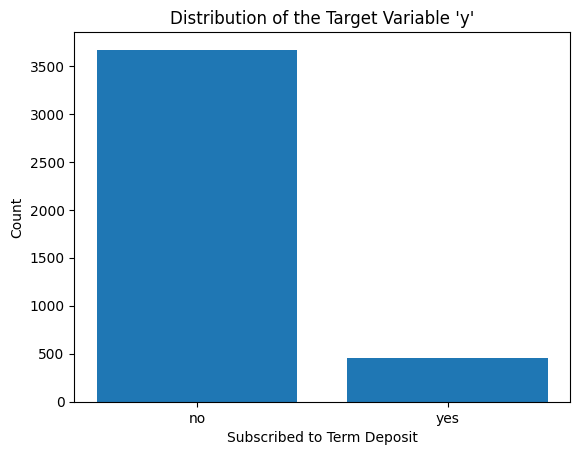

In [5]:
# Analyze the distribution of the target variable and comment on potential class imbalance
plt.bar(data.y.value_counts().index, data.y.value_counts().values)
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.title("Distribution of the Target Variable 'y'")
plt.show()

In [6]:
# Detect explicit and implicit missing values
missing_data = {
    'job': 'unknown',
    'marital': 'unknown',
    'education': 'unknown',
    'default': 'unknown',
    'housing': 'unknown',
    'loan': 'unknown',
    'pdays': 999,
    'poutcome': 'nonexistent',
}

data = data.replace(missing_data, pd.NA)

missing_summary = []

for col in data.columns:
    missing_count = data[col].isna().sum()
    
    if missing_count > 0:  # Only include columns with missing values
        missing_pct = (missing_count / len(data)) * 100
        missing_type = missing_data.get(col, 'N/A')
        
        missing_summary.append({
            'Column': col,
            'Missing_Type': missing_type,
            'Count': missing_count,
            'Percentage': f'{missing_pct:.1f}%'
        })

missing_df = pd.DataFrame(missing_summary)
display(missing_df)

,Column,Missing_Type,Count,Percentage
0,job,unknown,39,0.9%
1,marital,unknown,11,0.3%
2,education,unknown,167,4.1%
3,default,unknown,803,19.5%
4,housing,unknown,105,2.5%
5,loan,unknown,105,2.5%
6,pdays,999,3959,96.1%
7,poutcome,nonexistent,3523,85.5%


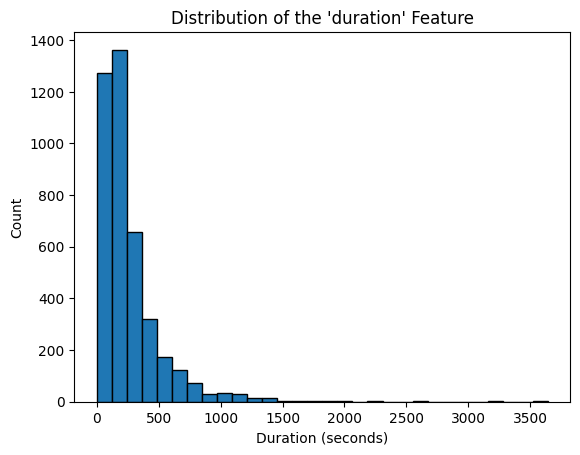

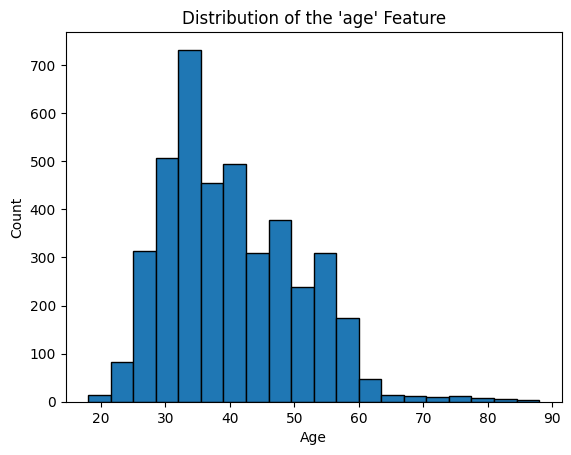

In [7]:
# Visualize the distribution of numerical variables

# Duration
plt.hist(data.duration, bins=30, edgecolor='black')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.title("Distribution of the 'duration' Feature")
plt.show()

# Age
plt.hist(data.age, bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title("Distribution of the 'age' Feature")
plt.show()

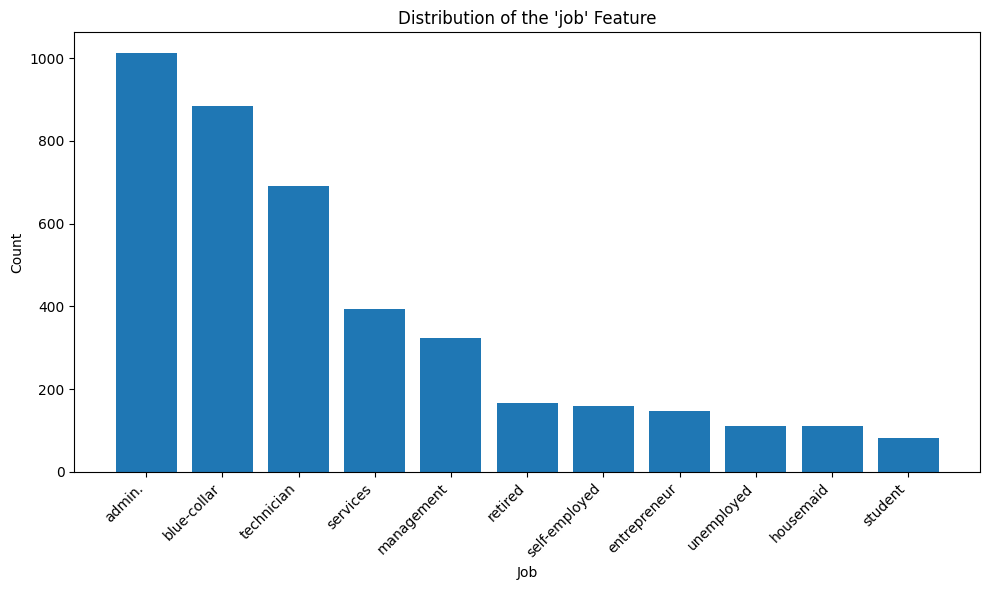

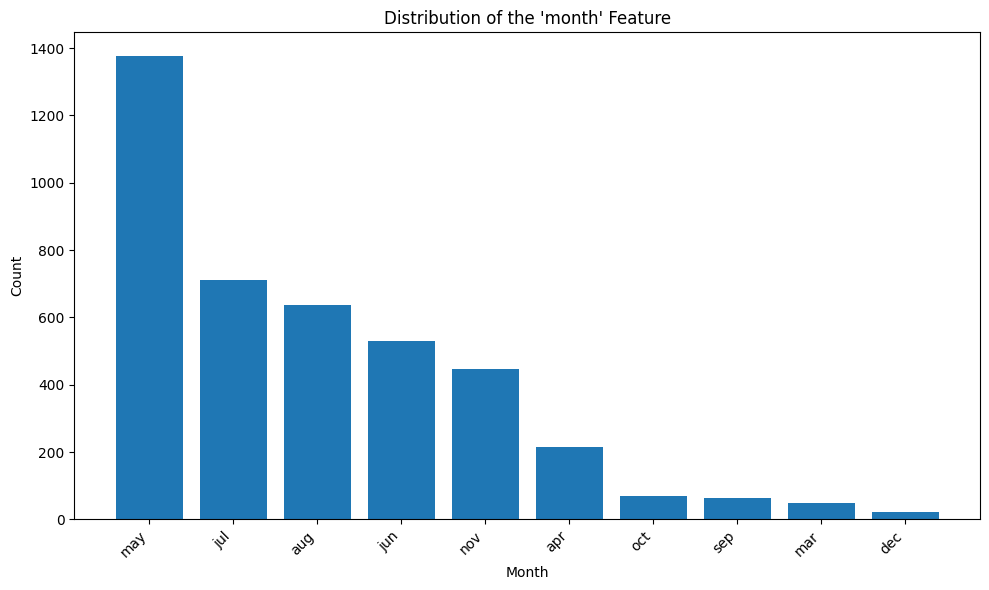

In [8]:
# Visualize the distribution of categorical variables

# Job
plt.figure(figsize=(10, 6))
plt.bar(data.job.value_counts().index, data.job.value_counts().values)
plt.xlabel('Job')
plt.ylabel('Count')
plt.title("Distribution of the 'job' Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Month
plt.figure(figsize=(10, 6))
plt.bar(data.month.value_counts().index, data.month.value_counts().values)
plt.xlabel('Month')
plt.ylabel('Count')
plt.title("Distribution of the 'month' Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Comments on categorical variable distributions:

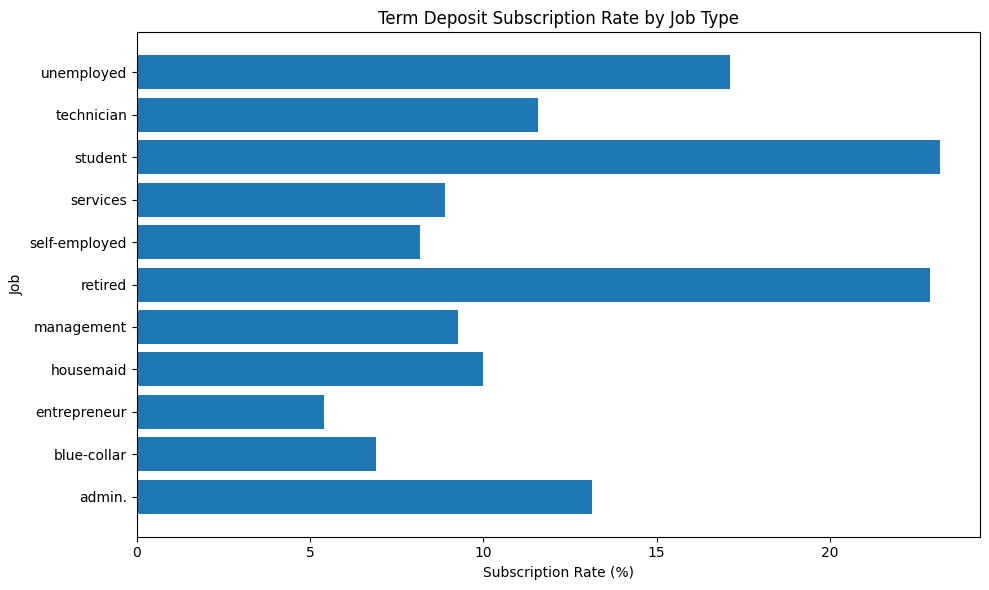

In [9]:
# Additional Analysis: Term Deposit Subscription Rate by Job Type
job_y_rate = data.groupby('job')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
plt.figure(figsize=(10, 6))
plt.barh(job_y_rate.index, job_y_rate.values)
plt.xlabel('Subscription Rate (%)')
plt.ylabel('Job')
plt.title('Term Deposit Subscription Rate by Job Type')
plt.tight_layout()
plt.show()